# DISCOVR EPIC L2
<br>

The DSCOVR Earth Polychromatic Imaging Camera (EPIC) observes the sunlit Earth from the Sun–Earth L1 point and captures full-disk images of the planet in 10 UV–visible–near-IR spectral bands roughly every 1–2 hours.

Level-2 products are geophysical retrievals derived from EPIC radiances. 

* Cloud properties: cloud mask, cloud optical thickness, cloud effective pressure/height/temperature, cloud phase
* Aerosols: aerosol optical depth, aerosol index
* Trace gases: total column ozone, sulfur dioxide (SO₂)
* Surface/vegetation: surface reflectivity, UV aerosol index, vegetation indices (e.g., NDVI)

This notebook will use two DISCOVR EPIC Level 2 products.

* DSCOVR_EPIC_L2_AER, Version 03, aerosols
* DSCOVR_EPIC_L2_TO3 Version 03, total column ozone (TO₃)

*Note: In a virtual machine in AWS us-west-2, where NASA cloud data is, the point matchups are fast. In Colab, say, your compute is not in the same data region nor provider, and the same matchups might take 10x longer.*

## Prerequisites

The examples here use NASA EarthData and you need to have an account with EarthData. Make sure you can login.

In [ ]:
# if needed
pip install point-collocation

In [2]:
import earthaccess
earthaccess.login()

## DSCOVR_EPIC_L2_AER

### Create some points

Random global and in 2024.

In [1]:
import pandas as pd
df_points = pd.read_csv(
    "fixtures/points_1000.csv",
    parse_dates=["time"]
)
df = df_points[
    (df_points["time"].dt.year == 2024)
]
print(len(df))
df.head()

31


,lat,lon,time,land
35,9.100711,11.216734,2024-07-21,True
43,-67.209878,-62.734423,2024-04-16,False
83,87.228338,-29.718344,2024-10-13,False
190,34.701655,-20.040258,2024-04-21,False
222,-8.043907,41.779801,2024-08-31,False


### Create the plan

In [2]:
%%time
import point_collocation as pc
short_name="DSCOVR_EPIC_L2_AER"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
        "version": "03"
    },
    time_buffer="6h"
)

CPU times: user 1.46 s, sys: 275 ms, total: 1.73 s
Wall time: 13.6 s


In [9]:
plan.summary(n=2)

Plan: 31 points → 90 unique granule(s)
  Points with 0 matches : 9
  Points with >1 matches: 18
  Time buffer: 0 days 06:00:00

First 2 point(s):
  [35] lat=9.1007, lon=11.2167, time=2024-07-21 00:00:00: 0 match(es)
  [43] lat=-67.2099, lon=-62.7344, time=2024-04-16 00:00:00: 0 match(es)


In [13]:
import xarray as xr
import earthaccess
results = earthaccess.search_data(
    short_name="DSCOVR_EPIC_L2_AER",
    temporal = ("2024-01-01", "2024-12-31"),
    version = "03"
)

In [32]:
f = earthaccess.open(results[100:101], pqdm_kwargs={"disable": True})
ds = xr.open_dataset(f[0], engine="h5netcdf", chunks={}, group="/HDFEOS/SWATHS/Aerosol NearUV Swath/Geolocation Fields")
ds.Latitude.values

/tmp/ipykernel_12837/585827809.py:2: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  ds = xr.open_dataset(f[0], engine="h5netcdf", chunks={}, group="/HDFEOS/SWATHS/Aerosol NearUV Swath/Geolocation Fields")


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(2048, 2048), dtype=float32)

In [46]:
earthaccess.download(results[0])

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

[PosixPath('/home/jovyan/point-collocation/examples/data/2026-03-16-b2ebee/DSCOVR_EPIC_L2_AER_03_20230201001752_03.he5')]

In [48]:
import h5py
import numpy as np
import json

paths = {
    "lat": "/HDFEOS/SWATHS/Aerosol NearUV Swath/Geolocation Fields/Latitude",
    "lon": "/HDFEOS/SWATHS/Aerosol NearUV Swath/Geolocation Fields/Longitude",
    "uvai": "/HDFEOS/SWATHS/Aerosol NearUV Swath/Data Fields/UVAerosolIndex",
    "aod": "/HDFEOS/SWATHS/Aerosol NearUV Swath/Data Fields/FinalAerosolOpticalDepth",
    "wavelength": "/HDFEOS/SWATHS/Aerosol NearUV Swath/Data Fields/Wavelength",
}

with h5py.File(f[0], "r") as h:
    lat = h[paths["lat"]][500:700, 800:1000]
    lon = h[paths["lon"]][500:700, 800:1000]
    uvai = h[paths["uvai"]][500:700, 800:1000]

np.savez(
    "epic_aer_subset.npz",
    lat=lat,
    lon=lon,
    uvai=uvai,
)

In [49]:
import json

sample = {
    "lat": lat[500:510, 800:810].tolist(),
    "lon": lon[500:510, 800:810].tolist(),
    "uvai": uvai[500:510, 800:810].tolist(),
}

with open("epic_debug_sample.json", "w") as f:
    json.dump(sample, f, indent=2)

In [26]:
dt = xr.open_datatree(f[0])
dt["/HDFEOS/SWATHS/Aerosol NearUV Swath/Geolocation Fields"].Latitude.values

/tmp/ipykernel_12837/2386113382.py:1: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  dt = xr.open_datatree(f[0])


array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(2048, 2048), dtype=float32)

In [35]:
short_name = "DSCOVR_EPIC_L2_AER"
version = "03"

results = earthaccess.search_data(
    short_name=short_name,
    version=version,
    temporal=("2023-02-01T00:00:00", "2023-02-01T04:59:59"),
)
len(results)

3

In [36]:
import xarray as xr
f = earthaccess.open(results)
ds = xr.open_dataset(f[0], group="/HDFEOS/SWATHS/Aerosol NearUV Swath/Geolocation Fields")

QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_12837/1323344285.py:3: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  ds = xr.open_dataset(f[0], group="/HDFEOS/SWATHS/Aerosol NearUV Swath/Geolocation Fields")


In [40]:
ds = xr.open_dataset(
    f[0],
    group="/HDFEOS/SWATHS/Aerosol NearUV Swath/Geolocation Fields",
    mask_and_scale=False,
    decode_cf=False,
)

/tmp/ipykernel_12837/1882213165.py:1: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  ds = xr.open_dataset(


In [43]:
import h5py
import numpy as np

with h5py.File(f[0], "r") as h:
    lat = h["/HDFEOS/SWATHS/Aerosol NearUV Swath/Geolocation Fields/Latitude"][:]
    print(np.nanmin(lat), np.nanmax(lat))
    print(np.unique(lat[:10, :10]))

-1.2676506e+30 65.678856
[-1.2676506e+30]


In [44]:
fill = ds.Latitude.attrs.get("_FillValue")
(ds.Latitude != fill).any().compute()

<xarray.DataArray 'Latitude' ()> Size: 1B
array(True)
Attributes:
    MissingValue:  -1.2676506e+30
    Title:         Geodetic Latitude (deg)
    Units:         deg
    _FillValue:    -1.2676506e+30

### Look at the variables

We will open a file with datatree and see what groups it has.

In [3]:
ds = plan.open_dataset(1, open_method="datatree")
ds

open_method: {'xarray_open': 'datatree', 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'merge': None, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None}


<xarray.DataTree>
Group: /
├── Group: /HDFEOS
│   ├── Group: /HDFEOS/ADDITIONAL
│   │   └── Group: /HDFEOS/ADDITIONAL/FILE_ATTRIBUTES
│   │           Attributes: (12/22)
│   │               ACF Filename:        acf_epic_sm_ffxt_aug2019.txt
│   │               AIRSCO_filename1:    AIRS.2016.05.08.L3.RetStd_IR001.v6.0.31.0.G161301816...
│   │               AIRSCO_filename2:    AIRS.2016.05.07.L3.RetStd_IR001.v6.0.31.0.G161291747...
│   │               AuthorAffiliation:   NASA/GSFC
│   │               AuthorName:          Omar Torres
│   │               EarthSunDistance:    0.9862366
│   │               ...                  ...
│   │               ProcessingCenter:    TLCF                                                ...
│   │               ProcessingHost:      Linux ominate.gsfc.nasa.gov 2.6.18-410.el5PAE #1 SMP...
│   │               ProductionDateTime:  2024-02-11T01:29:46.0Z
│   │               ShortName:           EPICAERUV
│   │               Time_Band340nm:      2024-02-08 01:57:26
│   │               Time_Band388nm:      2024-02-08 01:56:59
│   └── Group: /HDFEOS/SWATHS
│       └── Group: /HDFEOS/SWATHS/Aerosol NearUV Swath
│           ├── Group: /HDFEOS/SWATHS/Aerosol NearUV Swath/Data Fields
│           │       Dimensions:                         (phony_dim_0: 2048, phony_dim_1: 2048,
│           │                                            phony_dim_2: 5, phony_dim_3: 3,
│           │                                            phony_dim_4: 2)
│           │       Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2,
│           │                                       phony_dim_3, phony_dim_4
│           │       Data variables: (12/29)
│           │           AIRSCO_Flags                    (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
│           │           AIRSL3COvalue                   (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
│           │           AerosolAbsOpticalDepthVsHeight  (phony_dim_0, phony_dim_1, phony_dim_2, phony_dim_3) float32 252MB dask.array<chunksize=(256, 1024, 5, 3), meta=np.ndarray>
│           │           AerosolCorrCloudOpticalDepth    (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
│           │           AerosolOpticalDepthOverCloud    (phony_dim_0, phony_dim_1, phony_dim_3) float32 50MB dask.array<chunksize=(256, 1024, 2), meta=np.ndarray>
│           │           AerosolOpticalDepthVsHeight     (phony_dim_0, phony_dim_1, phony_dim_2, phony_dim_3) float32 252MB dask.array<chunksize=(256, 1024, 5, 3), meta=np.ndarray>
│           │           ...                              ...
│           │           Reflectivity                    (phony_dim_0, phony_dim_1, phony_dim_4) float32 34MB dask.array<chunksize=(256, 1024, 2), meta=np.ndarray>
│           │           Residue                         (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
│           │           SurfaceAlbedo                   (phony_dim_0, phony_dim_1, phony_dim_4) float32 34MB dask.array<chunksize=(256, 1024, 2), meta=np.ndarray>
│           │           SurfaceType                     (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
│           │           UVAerosolIndex                  (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
│           │           Wavelength                      (phony_dim_3) float32 12B dask.array<chunksize=(3,), meta=np.ndarray>
│           └── Group: /HDFEOS/SWATHS/Aerosol NearUV Swath/Geolocation Fields
│                   Dimensions:               (phony_dim_5: 2048, phony_dim_6: 2048)
│                   Dimensions without coordinates: phony_dim_5, phony_dim_6
│                   Data variables:
│                       Latitude              (phony_dim_5, phony_dim_6) float32 17MB dask.array<chunksize=(256, 102

 It does have groups; the latitude, longitude is at the base level: `/HDFEOS/SWATHS/Aerosol NearUV Swath/Data Fields` and the product is in `/HDFEOS/SWATHS/Aerosol NearUV Swath/Geolocation Fields`. We want `UVAerosolIndex`. We create a profile. We open a dataset with the profile to make sure it looks good.

In [4]:
%%time
discovr_epic_aer = {
    'xarray_open': 'dataset',
    'merge': ['/HDFEOS/SWATHS/Aerosol NearUV Swath/Geolocation Fields', '/HDFEOS/SWATHS/Aerosol NearUV Swath/Data Fields'],
    'open_kwargs': {'phony_dims':'access'}
}
ds = plan.open_dataset(1, open_method=discovr_epic_aer)
ds

open_method: {'xarray_open': 'dataset', 'merge': ['/HDFEOS/SWATHS/Aerosol NearUV Swath/Geolocation Fields', '/HDFEOS/SWATHS/Aerosol NearUV Swath/Data Fields'], 'open_kwargs': {'phony_dims': 'access', 'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge_kwargs': {}}
CPU times: user 335 ms, sys: 592 μs, total: 336 ms
Wall time: 3.89 s


<xarray.Dataset> Size: 2GB
Dimensions:                         (phony_dim_0: 2048, phony_dim_1: 2048,
                                     phony_dim_2: 5, phony_dim_3: 3,
                                     phony_dim_4: 2)
Coordinates:
    Latitude                        (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    Longitude                       (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2,
                                phony_dim_3, phony_dim_4
Data variables: (12/34)
    RelativeAzimuthAngle            (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    SnowIce_fraction                (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    SolarZenithAngle                (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    TerrainPressure                 (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    ViewingZenithAngle              (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    AIRSCO_Flags                    (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    ...                              ...
    Reflectivity                    (phony_dim_0, phony_dim_1, phony_dim_4) float32 34MB dask.array<chunksize=(256, 1024, 2), meta=np.ndarray>
    Residue                         (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    SurfaceAlbedo                   (phony_dim_0, phony_dim_1, phony_dim_4) float32 34MB dask.array<chunksize=(256, 1024, 2), meta=np.ndarray>
    SurfaceType                     (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    UVAerosolIndex                  (phony_dim_0, phony_dim_1) float32 17MB dask.array<chunksize=(256, 1024), meta=np.ndarray>
    Wavelength                      (phony_dim_3) float32 12B dask.array<chunksize=(3,), meta=np.ndarray>

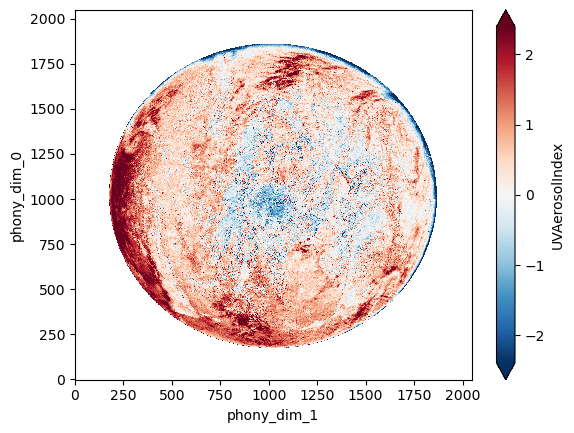

In [6]:
ds.UVAerosolIndex.plot(robust=True)

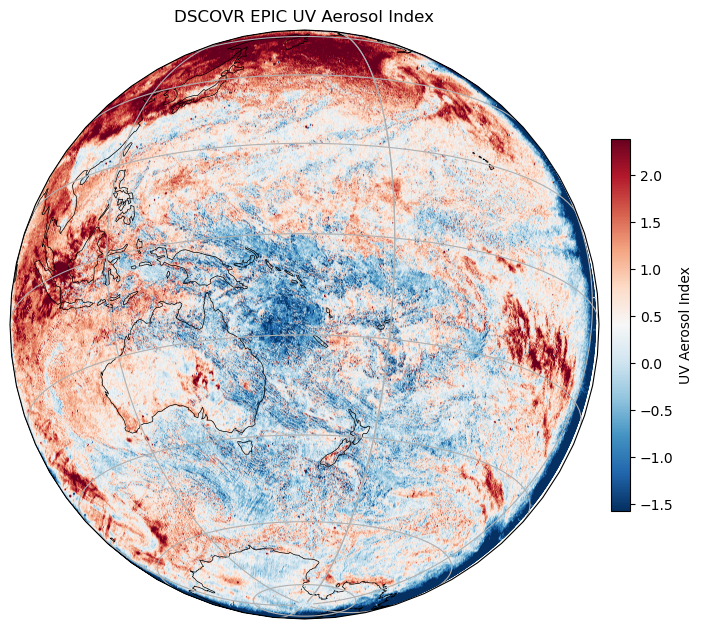

In [13]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np

vmin, vmax = np.nanpercentile(val, [2, 98])

# mask fill values
fill = ds.UVAerosolIndex.attrs["MissingValue"]
uvai = ds.UVAerosolIndex.where(ds.UVAerosolIndex != fill)

lat = ds.Latitude.values
lon = ds.Longitude.values
val = uvai.values

# flatten for scatter
lat = lat.flatten()
lon = lon.flatten()
val = val.flatten()

# projection center (mean location of valid pixels)
lat2d = ds.Latitude.values
lon2d = ds.Longitude.values

iy = lat2d.shape[0] // 2
ix = lat2d.shape[1] // 2

lat_m = float(lat2d[iy, ix])
lon_m = float(lon2d[iy, ix])

proj = ccrs.Orthographic(central_longitude=lon_m, central_latitude=lat_m)

fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection=proj)

# coastlines
ax.coastlines(linewidth=0.5)

# gridlines
grid = ax.gridlines(draw_labels=False)
grid.xformatter = LONGITUDE_FORMATTER
grid.yformatter = LATITUDE_FORMATTER

# plot swath
im = ax.scatter(
    lon,
    lat,
    c=val,
    s=1,
    cmap="RdBu_r",
    vmin=vmin,
    vmax=vmax,
    transform=ccrs.PlateCarree()
)

plt.colorbar(im, fraction=0.03, pad=0.02, label="UV Aerosol Index")

plt.title("DSCOVR EPIC UV Aerosol Index")
plt.show()

In [11]:
%%time
res = pc.matchup(plan, 
                 variables = ["UVAerosolIndex"], 
                 open_method=discovr_epic_aer)

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

...

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 1.18 s, sys: 223 ms, total: 1.4 s
Wall time: 13.9 s


ValueError: data must be finite, check for nan or inf values

In [15]:
# full res shows more info about matchups, like the granule lat lon
res[['lat', 'lon', 'time', 'vertical_column_troposphere']].dropna(subset=['vertical_column_troposphere']).head()

,lat,lon,time,vertical_column_troposphere
17,44.355987,-95.126999,2024-01-14 16:55:19,3.574082e+14
18,44.355987,-95.126999,2024-01-14 16:55:19,4.644599e+14
19,44.355987,-95.126999,2024-01-14 16:55:19,2.405348e+14
20,42.919232,-107.118997,2024-02-07 19:04:58,8.827827e+14
21,42.919232,-107.118997,2024-02-07 19:04:58,6.472115e+14


### Plot our points with data

In [18]:
ds = plan.open_dataset(2, open_method=tempo)

open_method: {'xarray_open': 'dataset', 'merge': ['/', '/product'], 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge_kwargs': {}}


In [19]:
ds["vertical_column_troposphere"].units

'molecules/cm^2'

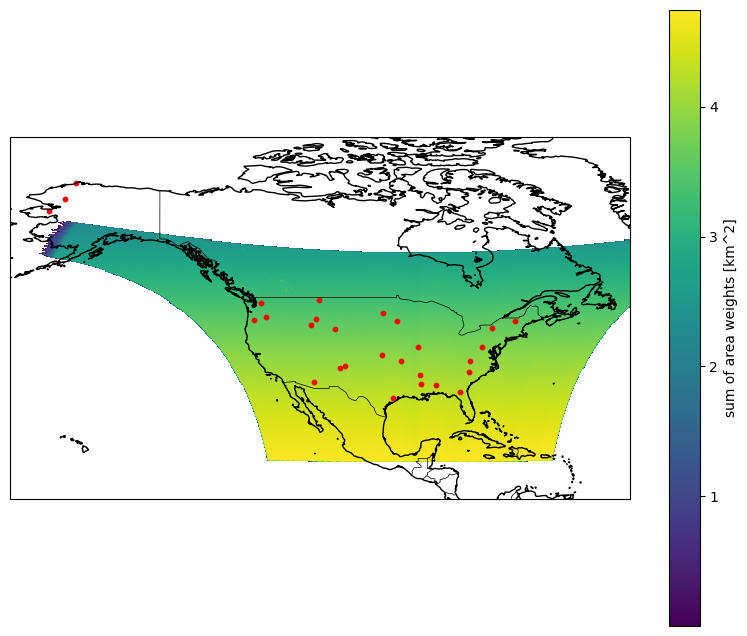

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10,8))

ds_plot = ds.weight.coarsen(latitude=10, longitude=10, boundary="trim").mean()

ax = plt.axes(projection=ccrs.PlateCarree())

# plot xarray field
ds_plot.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    add_colorbar=True
)

# coastlines
ax.coastlines(resolution="50m", linewidth=1)

# optional: borders
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# plot dataframe points
ax.scatter(
    df["lon"],
    df["lat"],
    color="red",
    s=10,
    transform=ccrs.PlateCarree(),
    label="points"
)

# zoom to North America
ax.set_extent([-170, -50, 10, 80], crs=ccrs.PlateCarree())

plt.show()

## TEMPO_O3TOT_L2

This is level 2 swath data. Let's take a look at how to get some matchups. The granule planning takes awhile so let's start with a few points.

In [30]:
import pandas as pd
df_points = pd.read_csv(
    "fixtures/points_1000_usa.csv",
    parse_dates=["time"]
)
df = df_points[
    (df_points["time"].dt.year == 2024) &
    (df_points["land"] == True) &
    (df_points["lon"] < -60) &
    (df_points["lon"] > -100)
    
]
print(len(df))
df.head()

15


,lat,lon,time,land
22,32.033815,-87.504205,2024-03-12 19:18:24,True
127,36.649735,-80.935069,2024-04-24 22:48:36,True
138,29.592103,-95.889008,2024-03-30 03:06:23,True
159,37.789200,-98.045855,2024-01-26 18:04:05,True
161,44.349757,-72.301856,2024-06-13 10:50:15,True


### Get the plan

In [31]:
%%time
import point_collocation as pc
short_name="TEMPO_O3TOT_L2"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
        "version": "V03"
    },
    time_buffer="1h"
)
plan.summary(n=1)

Plan: 15 points → 12 unique granule(s)
  Points with 0 matches : 9
  Points with >1 matches: 4
  Time buffer: 0 days 01:00:00

First 1 point(s):
  [22] lat=32.0338, lon=-87.5042, time=2024-03-12 19:18:24: 1 match(es)
    → https://data.asdc.earthdata.nasa.gov/asdc-prod-protected/TEMPO/TEMPO_O3TOT_L2_V03/2024.03.12/TEMPO_O3TOT_L2_V03_20240312T190833Z_S010G04.nc
CPU times: user 2.7 s, sys: 265 ms, total: 2.96 s
Wall time: 39.3 s


### Take a look at the granules

These are grouped netcdfs and we need to figure out what groups we need and variable names.

In [16]:
ds = plan.open_dataset(0, open_method="datatree")
ds

open_method: {'xarray_open': 'datatree', 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'merge': None, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None}


<xarray.DataTree>
Group: /
│   Dimensions:      (xtrack: 2048, mirror_step: 131)
│   Coordinates:
│     * xtrack       (xtrack) int32 8kB 0 1 2 3 4 5 ... 2043 2044 2045 2046 2047
│     * mirror_step  (mirror_step) int32 524B 132 133 134 135 ... 259 260 261 262
│   Attributes: (12/34)
│       time_reference:                   1980-01-06T00:00:00Z
│       scan_num:                         1
│       granule_num:                      2
│       time_coverage_start:              2024-01-03T12:59:34Z
│       time_coverage_end:                2024-01-03T13:06:11Z
│       time_coverage_start_since_epoch:  1388321992.512726
│       ...                               ...
│       title:                            TEMPO Level 2 total ozone product
│       collection_shortname:             TEMPO_O3TOT_L2
│       collection_version:               1
│       keywords:                         EARTH SCIENCE>ATMOSPHERE>ATMOSPHERIC CH...
│       summary:                          Total ozone Level 2 files provide ozone...
│       coremetadata:                     \nGROUP                  = INVENTORYMET...
├── Group: /product
│       Dimensions:               (mirror_step: 131, xtrack: 2048)
│       Data variables:
│           column_amount_o3      (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           radiative_cloud_frac  (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           fc                    (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           quality_flag          (mirror_step, xtrack) int32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           o3_below_cloud        (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           so2_index             (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           uv_aerosol_index      (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
├── Group: /geolocation
│       Dimensions:                 (mirror_step: 131, xtrack: 2048, corner: 4)
│       Coordinates:
│           time                    (mirror_step) datetime64[ns] 1kB dask.array<chunksize=(131,), meta=np.ndarray>
│           latitude                (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           longitude               (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│       Dimensions without coordinates: corner
│       Data variables:
│           latitude_bounds         (mirror_step, xtrack, corner) float32 4MB dask.array<chunksize=(131, 2048, 4), meta=np.ndarray>
│           longitude_bounds        (mirror_step, xtrack, corner) float32 4MB dask.array<chunksize=(131, 2048, 4), meta=np.ndarray>
│           solar_zenith_angle      (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           solar_azimuth_angle     (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           viewing_zenith_angle    (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           viewing_azimuth_angle   (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           relative_azimuth_angle  (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
├── Group: /support_data
│       Dimensions:                        (mirror_step: 131, xtrack: 2048,
│                                           wavelength: 12, layer: 11)
│       Dimensions without coordinates: wavelength, layer
│       Data variables: (12/21)
│           ground_pixel_quality_flag      (mirror_step, xtrack) int32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
│           lut_wavelength                 (wavelength) float32 48B dask.array<chunksize=(12,), meta=np.ndarray>
│           cloud_pressure         

### Ok now we know the groups

We will make a open_method dictionary.

In [34]:
tempo_l2 = {
    'xarray_open': 'dataset',
    'merge': ['/product', '/geolocation'],
    'coords': {'lat': 'latitude', 'lon': 'longitude'},
}
ds = plan.open_dataset(0, open_method=tempo_l2)
ds

open_method: {'xarray_open': 'dataset', 'merge': ['/product', '/geolocation'], 'coords': {'lat': 'latitude', 'lon': 'longitude'}, 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge_kwargs': {}}


<xarray.Dataset> Size: 24MB
Dimensions:                 (mirror_step: 131, xtrack: 2048, corner: 4)
Coordinates:
    time                    (mirror_step) datetime64[ns] 1kB dask.array<chunksize=(131,), meta=np.ndarray>
    latitude                (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    longitude               (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
Dimensions without coordinates: mirror_step, xtrack, corner
Data variables: (12/14)
    column_amount_o3        (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    radiative_cloud_frac    (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    fc                      (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    quality_flag            (mirror_step, xtrack) int32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    o3_below_cloud          (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    so2_index               (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    ...                      ...
    longitude_bounds        (mirror_step, xtrack, corner) float32 4MB dask.array<chunksize=(131, 2048, 4), meta=np.ndarray>
    solar_zenith_angle      (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    solar_azimuth_angle     (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    viewing_zenith_angle    (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    viewing_azimuth_angle   (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>
    relative_azimuth_angle  (mirror_step, xtrack) float32 1MB dask.array<chunksize=(131, 2048), meta=np.ndarray>

### Now we get the matchups using this open_method dict

It is roughly 2 seconds per point. So roughly 5 hrs for 10,000 points.

In [36]:
%%time
res = pc.matchup(plan, 
                 variables = ["uv_aerosol_index"], 
                 open_method=tempo_l2)

CPU times: user 13.2 s, sys: 754 ms, total: 13.9 s
Wall time: 31.4 s


In [37]:
(
    res[['lat', 'lon', 'time', 'uv_aerosol_index']]
        .dropna(subset=['uv_aerosol_index'])
)

,lat,lon,time,uv_aerosol_index
0,32.033815,-87.504205,2024-03-12 19:18:24,-2.219414
1,36.649735,-80.935069,2024-04-24 22:48:36,-2.591015
4,44.349757,-72.301856,2024-06-13 10:50:15,-1.152082
5,44.349757,-72.301856,2024-06-13 10:50:15,-1.889225
6,44.355987,-95.126999,2024-01-14 16:55:19,-2.514838
7,44.355987,-95.126999,2024-01-14 16:55:19,-2.738163
9,34.035328,-90.559024,2024-07-31 23:17:20,-2.717468
10,34.035328,-90.559024,2024-07-31 23:17:20,-2.282551
11,34.035328,-90.559024,2024-07-31 23:17:20,-1.936824
17,45.961109,-97.761663,2024-07-01 12:06:54,-1.305435


### Here is a plot showing points and swaths

This is just one swath. The matchup routine finds the granules matching each point.

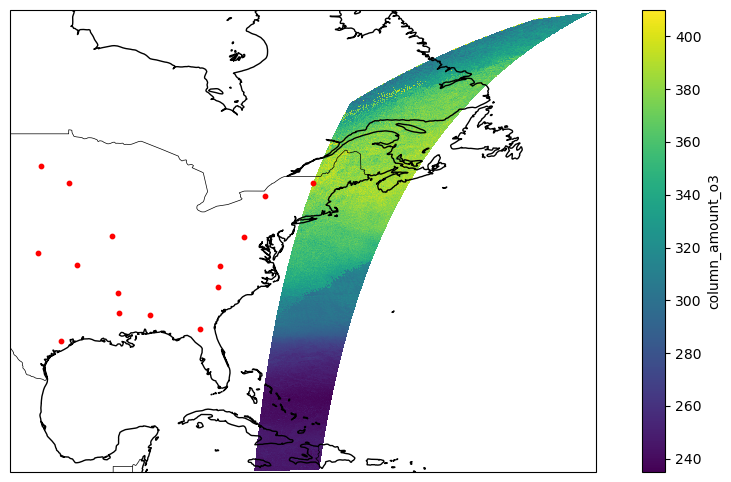

In [38]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

var = ds["column_amount_o3"]

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

pcm = ax.pcolormesh(
    ds["longitude"],
    ds["latitude"],
    var,
    shading="auto",
    transform=ccrs.PlateCarree()
)

# plot dataframe points
ax.scatter(
    df["lon"],
    df["lat"],
    color="red",
    s=10,
    transform=ccrs.PlateCarree(),
    label="points"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(pcm, ax=ax, label=var.name)
plt.show()